# Introduction to Probabilistic Programming: a hierarchical model in NumPyro

**The question:** *Twelve hospitals perform the same operation. Which ones have worse
complication rates than the rest?*

The obvious answer is to divide complications by patients and rank the hospitals. This
notebook shows why that answer is misleading, and how a **hierarchical (multilevel)
Bayesian model** gives a better one. We'll write the model in a few lines of
[NumPyro](https://num.pyro.ai) and let it handle the inference.

**The main path (about 15 minutes)**
1. Look at the data
2. Write three models: complete, no and partial pooling
3. Fit them and check the sampler
4. Compare the estimates: shrinkage
5. Answer the question

**Extras** at the end are for self-study: Bayes for one hospital, a prior predictive
check, why the model is written in "non-centred" form, a posterior predictive check,
rankings, and predictions for a new hospital.

> **Running this:** on Google Colab, run the first cell to install NumPyro. Locally, use
> `pip install -r requirements.txt`.

In [1]:
# Colab only: install NumPyro (JAX is preinstalled there). Harmless elsewhere.
import importlib.util, subprocess, sys
if importlib.util.find_spec("numpyro") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "numpyro"], check=True)

In [2]:
import numpyro
numpyro.set_host_device_count(4)   # let us run 4 MCMC chains in parallel on a CPU

import jax
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, Predictive
from scipy import stats

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
print("numpyro", numpyro.__version__, "| jax", jax.__version__)

/Users/chris-eda2/BDAS/Probabilistic-Programming-Tutorial/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


numpyro 0.22.0 | jax 0.11.2


## 1. The data

We **simulate** the data so that we know the true complication rate of every hospital.
That way we can check which method gets closest to the truth. In real life you never get
to see `true_rate`.

In [3]:
rng = np.random.default_rng(0)

n_patients = np.array([8, 12, 15, 22, 30, 45, 60, 85, 120, 180, 260, 400])
n_hosp = len(n_patients)
names = [f"H{i+1:02d}" for i in range(n_hosp)]

true_mu, true_tau = -1.8, 0.30                          # population on the log-odds scale
true_logit = rng.normal(true_mu, true_tau, size=n_hosp)
true_rate = 1 / (1 + np.exp(-true_logit))
complications = rng.binomial(n_patients, true_rate)
raw = complications / n_patients

df = pd.DataFrame({
    "hospital": names,
    "patients": n_patients,
    "complications": complications,
    "raw_rate": raw.round(3),
    "true_rate": true_rate.round(3),   # hidden in real life!
})
df

,hospital,patients,complications,raw_rate,true_rate
0,H01,8,2,0.250,0.147
1,H02,12,0,0.000,0.137
2,H03,15,3,0.200,0.167
3,H04,22,2,0.091,0.146
4,H05,30,6,0.200,0.123
5,H06,45,7,0.156,0.156
6,H07,60,10,0.167,0.196
7,H08,85,15,0.176,0.180
8,H09,120,8,0.067,0.118
9,H10,180,14,0.078,0.102


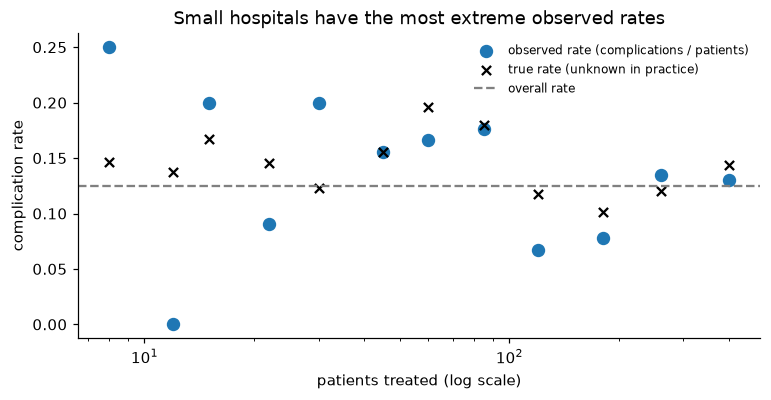

In [4]:
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.scatter(n_patients, raw, s=60, label="observed rate (complications / patients)")
ax.scatter(n_patients, true_rate, marker="x", color="k", label="true rate (unknown in practice)")
ax.axhline(complications.sum() / n_patients.sum(), ls="--", c="grey", label="overall rate")
ax.set_xscale("log"); ax.set_xlabel("patients treated (log scale)"); ax.set_ylabel("complication rate")
ax.legend(frameon=False, fontsize=8); ax.set_title("Small hospitals have the most extreme observed rates")
plt.show()

**Notice:** the most extreme observed rates, 25% at H01 and 0% at H02, come from the two
*smallest* hospitals. With 8 patients, one extra complication moves the rate by 12.5
percentage points. Ranking hospitals on raw rates mostly ranks them by **noise**.

## 2. Three models

| | Assumption | Problem |
|---|---|---|
| **Complete pooling** | every hospital has the *same* rate | ignores real differences |
| **No pooling** | every hospital is *unrelated* to the others | small hospitals get wild estimates |
| **Partial pooling** (hierarchical) | hospitals are *different but related*: drawn from a common population | the population spread is *learned from the data* |

Reading the code:
* `numpyro.sample("name", distribution)` declares an unknown quantity with a prior.
* Adding `obs=y` ties it to the data instead: that's the likelihood.
* `numpyro.plate` means "repeat for every hospital" (a vectorised for-loop).

In [5]:
def complete_pooling(n, y=None):
    p = numpyro.sample("p", dist.Beta(2, 10))                  # ONE rate shared by all
    with numpyro.plate("hospital", len(n)):
        numpyro.sample("y", dist.Binomial(n, probs=p), obs=y)


def no_pooling(n, y=None):
    with numpyro.plate("hospital", len(n)):
        p = numpyro.sample("p", dist.Beta(2, 10))              # a separate, independent rate each
        numpyro.sample("y", dist.Binomial(n, probs=p), obs=y)


def partial_pooling(n, y=None):
    # Population-level parameters, on the log-odds scale
    mu = numpyro.sample("mu", dist.Normal(-1.5, 1.0))          # typical hospital
    tau = numpyro.sample("tau", dist.HalfNormal(1.0))          # how much hospitals differ
    with numpyro.plate("hospital", len(n)):
        # theta ~ Normal(mu, tau), written as mu + tau * z because it samples more
        # reliably ("non-centred"; see Extra C)
        z = numpyro.sample("z", dist.Normal(0, 1))
        theta = numpyro.deterministic("theta", mu + tau * z)   # each hospital's log-odds
        numpyro.deterministic("p", jax.nn.sigmoid(theta))      # report as a rate
        numpyro.sample("y", dist.Binomial(n, logits=theta), obs=y)

The new idea in `partial_pooling` is that the hospital rates have a prior whose parameters
(`mu`, `tau`) are **themselves unknown and estimated**. That's what "hierarchical" means.
If the data say `tau` is near 0, hospitals are pooled completely; if `tau` is large, each
stands alone. The model **learns where it sits between the two**.

## 3. Fit and check

NUTS draws samples from the posterior. We run 4 independent chains so we can check they agree.

In [6]:
def fit(model, seed=0):
    mcmc = MCMC(NUTS(model), num_warmup=1000, num_samples=1000, num_chains=4, progress_bar=False)
    mcmc.run(jax.random.PRNGKey(seed), n=n_patients, y=complications)
    return mcmc

fit_complete = fit(complete_pooling)
fit_none = fit(no_pooling)
fit_partial = fit(partial_pooling)

fit_partial.print_summary(exclude_deterministic=True)


                mean       std    median      5.0%     95.0%     n_eff     r_hat
        mu     -1.94      0.14     -1.95     -2.16     -1.70   1668.12      1.00
       tau      0.29      0.18      0.27      0.00      0.52   1045.69      1.00
      z[0]      0.24      0.94      0.25     -1.33      1.80   4687.72      1.00
      z[1]     -0.39      0.99     -0.41     -1.87      1.31   4155.24      1.00
      z[2]      0.24      0.92      0.25     -1.38      1.62   5417.08      1.00
      z[3]     -0.20      0.93     -0.23     -1.79      1.25   5403.94      1.00
      z[4]      0.39      0.86      0.41     -1.02      1.78   3845.91      1.00
      z[5]      0.19      0.82      0.20     -1.04      1.64   5321.12      1.00
      z[6]      0.33      0.84      0.33     -1.02      1.72   4407.17      1.00
      z[7]      0.53      0.80      0.55     -0.73      1.88   3518.37      1.00
      z[8]     -0.88      0.82     -0.92     -2.22      0.45   3259.24      1.00
      z[9]     -0.85      0

Before trusting the results, check three things:

* **`r_hat`** ≤ 1.01: the chains agree with each other.
* **`n_eff`** (effective sample size) in the hundreds or more.
* **divergences** = 0: the sampler explored the whole posterior.

All three pass. The posterior for `tau` is centred near 0.3, the spread we simulated with:
the model has learned how much hospitals differ.

## 4. Shrinkage

Compare the three models' estimates of each hospital's rate against the truth.

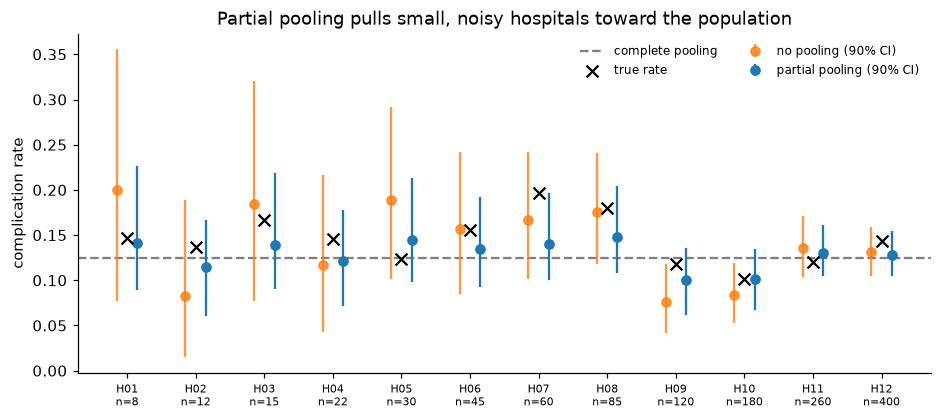

In [7]:
post = fit_partial.get_samples()

def rate_summary(samples):
    p = np.asarray(samples)
    return p.mean(0), *np.percentile(p, [5, 95], axis=0)

pc = np.full(n_hosp, float(fit_complete.get_samples()["p"].mean()))
pn, pn_lo, pn_hi = rate_summary(fit_none.get_samples()["p"])
pp, pp_lo, pp_hi = rate_summary(post["p"])

x = np.arange(n_hosp)
labels = [f"{h}\nn={n}" for h, n in zip(names, n_patients)]
fig, ax = plt.subplots(figsize=(10, 4))
ax.axhline(pc[0], c="grey", ls="--", label="complete pooling")
ax.errorbar(x - 0.15, pn, [pn - pn_lo, pn_hi - pn], fmt="o", c="tab:orange", alpha=0.8, label="no pooling (90% CI)")
ax.errorbar(x + 0.15, pp, [pp - pp_lo, pp_hi - pp], fmt="o", c="tab:blue", label="partial pooling (90% CI)")
ax.scatter(x, true_rate, marker="x", c="k", s=60, zorder=4, label="true rate")
ax.set_xticks(x, labels, fontsize=7)
ax.set_ylabel("complication rate"); ax.legend(frameon=False, fontsize=8, ncol=2)
ax.set_title("Partial pooling pulls small, noisy hospitals toward the population")
plt.show()

**Shrinkage:** the hierarchical model pulls the estimates for small hospitals (left) toward
the population average, because their own data are weak. Large hospitals (right) barely
move. How much to pull is **learned from the data** through `tau`.

Because this is a simulation, we can score each method against the truth:

In [8]:
errors = pd.DataFrame({
    "raw rate (no model)": np.abs(raw - true_rate),
    "complete pooling": np.abs(pc - true_rate),
    "no pooling (Bayes)": np.abs(pn - true_rate),
    "partial pooling": np.abs(pp - true_rate),
}, index=names)
(errors.mean() * 100).round(2).rename("mean absolute error (percentage points)").to_frame()

,mean absolute error (percentage points)
raw rate (no model),4.51
complete pooling,2.57
no pooling (Bayes),2.86
partial pooling,2.10


Partial pooling has the lowest average error: it borrows strength across hospitals while
still letting genuinely different hospitals stand out.

## 5. Answer the question: which hospitals are worse than typical?

With posterior samples, any question is a line of NumPy. Here: the probability that each
hospital's log-odds is above the population average, $P(\theta_j > \mu \mid \text{data})$.

In [9]:
p_worse = np.asarray((post["theta"] > post["mu"][:, None]).mean(0))
out = pd.DataFrame({"patients": n_patients, "raw_rate": raw.round(3),
                    "posterior_mean": pp.round(3), "P(worse than typical)": p_worse.round(2)},
                   index=names)
out.sort_values("P(worse than typical)", ascending=False)

,patients,raw_rate,posterior_mean,P(worse than typical)
H08,85,0.176,0.147,0.76
H05,30,0.200,0.144,0.69
H07,60,0.167,0.140,0.66
H01,8,0.250,0.141,0.61
H03,15,0.200,0.140,0.61
H06,45,0.156,0.135,0.60
H11,260,0.135,0.131,0.59
H12,400,0.130,0.128,0.56
H04,22,0.091,0.121,0.41
H02,12,0.000,0.115,0.35


On raw rates, H01 (2 of 8 patients, 25%) looks like the worst hospital. The model says it is
roughly a coin flip whether H01 is even above average. No hospital is confidently worse
than typical, while H09 and H10 are fairly confidently *better*: their low rates rest on
120 and 180 patients. Probabilities like these are a far more honest basis for decisions
than a league table.

## Takeaways

1. **A probabilistic program is a generative story written as code.** You describe how the
   data arise, and the inference engine (here NUTS) does the rest.
2. **Hierarchical models sit between "all the same" and "all different".** The data decide
   where, through the population spread `tau`.
3. **Shrinkage is a feature, not a bug.** Small groups borrow strength and their error drops.
4. **Check before you trust:** `r_hat`, effective sample size, divergences.
5. **The same pattern shows up everywhere:** patients within clinics, students within
   schools, cells within subjects, users within regions, repeated measurements within people.

---

# Extras for self-study

## A. Bayes for one hospital: exact answer vs MCMC

For a single hospital with a $\text{Beta}(2, 10)$ prior and a Binomial likelihood, the
posterior has a closed form: $\text{Beta}(2 + y,\; 10 + n - y)$. That lets us check MCMC.

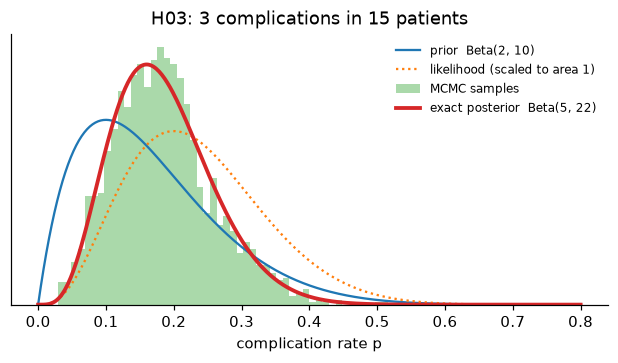

exact posterior mean: 0.185
MCMC  posterior mean: 0.185


In [10]:
j = 2                                       # hospital H03
y_j, n_j = complications[j], n_patients[j]
a0, b0 = 2, 10

def one_hospital(n, y=None):
    p = numpyro.sample("p", dist.Beta(2, 10))               # prior
    numpyro.sample("y", dist.Binomial(n, probs=p), obs=y)   # likelihood

mcmc = MCMC(NUTS(one_hospital), num_warmup=500, num_samples=2000, progress_bar=False)
mcmc.run(jax.random.PRNGKey(0), n=n_j, y=y_j)
p_samples = mcmc.get_samples()["p"]

p_grid = np.linspace(0, 0.8, 400)
lik = stats.binom(n_j, p_grid).pmf(y_j)
plt.figure(figsize=(7, 3.2))
plt.plot(p_grid, stats.beta(a0, b0).pdf(p_grid), label="prior  Beta(2, 10)")
plt.plot(p_grid, lik / np.trapezoid(lik, p_grid), ls=":", label="likelihood (scaled to area 1)")
plt.hist(np.asarray(p_samples), bins=50, density=True, alpha=0.4, label="MCMC samples")
plt.plot(p_grid, stats.beta(a0 + y_j, b0 + n_j - y_j).pdf(p_grid), lw=2.5,
         label=f"exact posterior  Beta({a0 + y_j}, {b0 + n_j - y_j})")
plt.xlabel("complication rate p"); plt.yticks([]); plt.legend(frameon=False, fontsize=8)
plt.title(f"{names[j]}: {y_j} complications in {n_j} patients"); plt.show()

print(f"exact posterior mean: {(a0 + y_j) / (a0 + b0 + n_j):.3f}")
print(f"MCMC  posterior mean: {p_samples.mean():.3f}")

## B. Prior predictive check: does the model make sense before seeing data?

Leave out `y` and the model simulates fake datasets from the prior. If these look absurd,
the priors need rethinking.

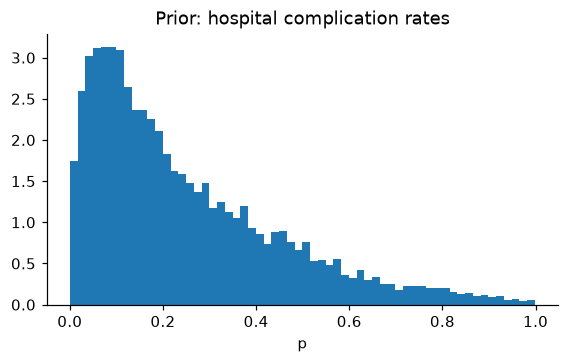

Prior 90% interval for a hospital's rate: [0.026 0.667]


In [11]:
prior = Predictive(partial_pooling, num_samples=1000)(jax.random.PRNGKey(1), n=n_patients)

plt.figure(figsize=(6, 3.2))
plt.hist(np.asarray(prior["p"]).ravel(), bins=60, density=True)
plt.title("Prior: hospital complication rates"); plt.xlabel("p"); plt.show()
print("Prior 90% interval for a hospital's rate:",
      np.percentile(np.asarray(prior["p"]), [5, 95]).round(3))

The prior allows rates from about 3% to 67%: far wider than we really believe, but it
rules out nothing plausible. Priors like this are called **weakly informative**.

## C. Why write the model as `mu + tau * z`?

The more obvious "centred" version draws `theta ~ Normal(mu, tau)` directly. It describes
the same model, but when `tau` is small the `theta`s must squeeze tightly around `mu`, and
the posterior takes the shape of a narrow **funnel** that the sampler struggles to explore.
The warning sign is **divergences**.

     centred: 55 divergences
 non-centred: 0 divergences


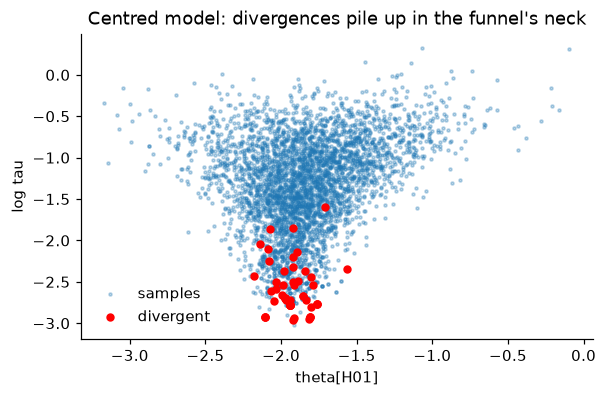

In [12]:
def partial_pooling_centred(n, y=None):
    mu = numpyro.sample("mu", dist.Normal(-1.5, 1.0))
    tau = numpyro.sample("tau", dist.HalfNormal(1.0))
    with numpyro.plate("hospital", len(n)):
        theta = numpyro.sample("theta", dist.Normal(mu, tau))
        numpyro.sample("y", dist.Binomial(n, logits=theta), obs=y)

fit_centred = fit(partial_pooling_centred)
for label, m in [("centred", fit_centred), ("non-centred", fit_partial)]:
    print(f"{label:>12}: {int(m.get_extra_fields()['diverging'].sum())} divergences")

s = fit_centred.get_samples()
div = fit_centred.get_extra_fields()["diverging"]
plt.figure(figsize=(6, 3.6))
plt.scatter(s["theta"][:, 0], np.log(s["tau"]), s=4, alpha=0.3, label="samples")
plt.scatter(s["theta"][div, 0], np.log(s["tau"][div]), s=20, c="red", label="divergent")
plt.xlabel(f"theta[{names[0]}]"); plt.ylabel("log tau"); plt.legend(frameon=False)
plt.title("Centred model: divergences pile up in the funnel's neck"); plt.show()

Writing $\theta_j = \mu + \tau z_j$ with $z_j \sim \text{Normal}(0, 1)$ gives the sampler
a nice round shape to explore instead. NumPyro can apply this automatically with
`numpyro.handlers.reparam` and `LocScaleReparam(centered=0)`.

## D. Posterior predictive check: can the fitted model reproduce the data?

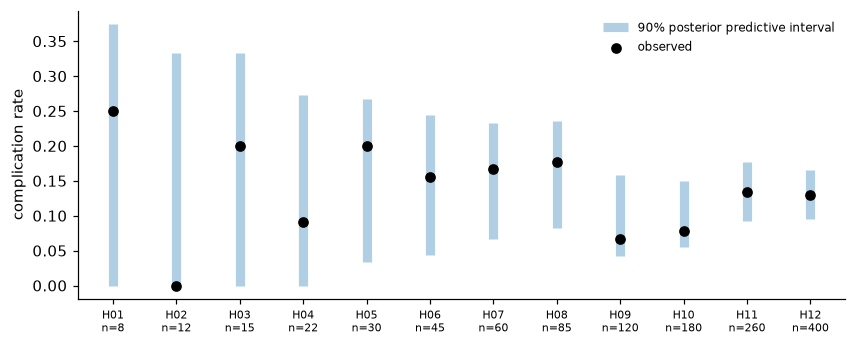

In [13]:
ppc = Predictive(partial_pooling, post)(jax.random.PRNGKey(2), n=n_patients)
ppc_rate = np.asarray(ppc["y"]) / n_patients
lo, hi = np.percentile(ppc_rate, [5, 95], axis=0)

plt.figure(figsize=(9, 3.4))
plt.vlines(x, lo, hi, lw=6, alpha=0.35, label="90% posterior predictive interval")
plt.scatter(x, raw, c="k", zorder=3, label="observed")
plt.xticks(x, labels, fontsize=7)
plt.ylabel("complication rate"); plt.legend(frameon=False, fontsize=8); plt.show()

Every observed rate falls inside what the model expects.

## E. How certain are the rankings?
Rank the hospitals within every posterior sample (1 = lowest rate) to get a distribution of ranks.

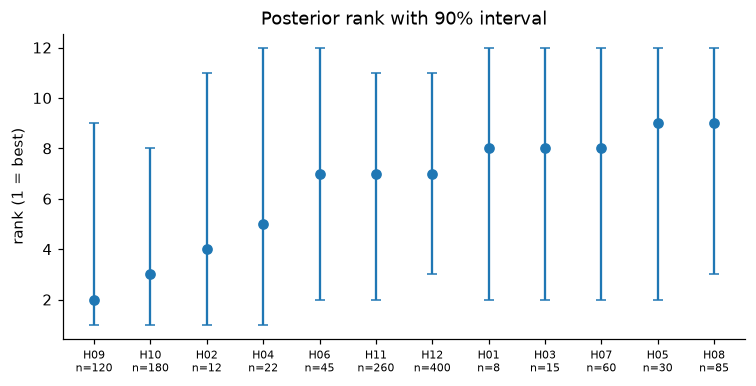

In [14]:
ranks = np.asarray(post["p"]).argsort(1).argsort(1) + 1
r_lo, r_med, r_hi = np.percentile(ranks, [5, 50, 95], axis=0)
order = np.argsort(r_med)

plt.figure(figsize=(8, 3.6))
plt.errorbar(x, r_med[order], [r_med[order] - r_lo[order], r_hi[order] - r_med[order]], fmt="o", capsize=3)
plt.xticks(x, [labels[i] for i in order], fontsize=7)
plt.ylabel("rank (1 = best)"); plt.title("Posterior rank with 90% interval"); plt.show()

Most rank intervals are wide: a league table on raw rates would show false precision.

## F. What should we expect from a new hospital?
Draw its rate from the population, then simulate its first 50 patients.

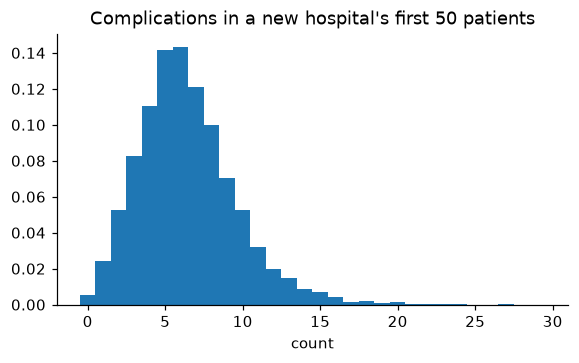

90% interval: [ 2. 12.]


In [15]:
key1, key2 = jax.random.split(jax.random.PRNGKey(3))
theta_new = post["mu"] + post["tau"] * jax.random.normal(key1, post["mu"].shape)
y_new = dist.Binomial(50, logits=theta_new).sample(key2)

plt.figure(figsize=(6, 3.2))
plt.hist(np.asarray(y_new), bins=np.arange(-0.5, 30), density=True)
plt.title("Complications in a new hospital's first 50 patients"); plt.xlabel("count"); plt.show()
print("90% interval:", np.percentile(np.asarray(y_new), [5, 95]))

## Try it yourself

* **Change the data:** give H01 8 complications out of 8 patients. How far does partial
  pooling pull it back?
* **Change the prior:** set `tau ~ HalfNormal(0.1)` or `HalfNormal(5)`. What happens to
  the shrinkage?
* **Add a predictor:** give each hospital a covariate (e.g. teaching vs non-teaching) and
  model `theta = mu + beta * teaching + tau * z`.
* **Go patient-level:** simulate individual patients with an age covariate and fit a
  hierarchical logistic regression with `dist.Bernoulli(logits=...)`.
* **Compare models** with leave-one-out cross-validation using
  [ArviZ](https://python.arviz.org) (`az.from_numpyro`, `az.loo`, `az.compare`).

## Further reading

* McElreath, *Statistical Rethinking* (2nd ed.). An accessible intro with lectures on
  YouTube; the [NumPyro port](https://fehiepsi.github.io/rethinking-numpyro/) of its code is free online.
* Gelman et al., *Bayesian Data Analysis* (3rd ed., free PDF). The reference text.
* Gelman et al., ["Bayesian Workflow"](https://arxiv.org/abs/2011.01808) (2020).
* [NumPyro examples gallery](https://num.pyro.ai/en/stable/examples.html), including
  eight schools, the classic hierarchical model.